In [1]:
import numpy as np
import os 
os.environ['KERAS_BACKEND'] = 'torch'
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from models_code.rnn import rnn
import pandas as pd

In [2]:
cpi = pd.read_csv('..\\data\\structured_data\\CPI_growth_yoy_dataframe.csv')
rgdp = pd.read_csv('..\\data\\structured_data\\RGDP_growth_dataframe.csv')
unemp = pd.read_csv('..\\data\\structured_data\\unemployment_rate_dataframe.csv')
# dropping the unwanted duplicate columns and indexes, renaming the observed value columns
cpi = cpi.drop(['Unnamed: 0'], axis = 1).rename(columns = {'OBS_VALUE': 'CPI inflation'})
rgdp = rgdp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'RGDP growth'})
unemp = unemp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'Unemp rate'})
# concatenating along the columns
df = pd.concat((cpi, rgdp, unemp), axis = 1)

tuning the model on vaidation data: 


c:\python projects\Economics_forecasting\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:887: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n = torch._VF.gru(


best config is:
number of lags: 16
1st GRU layer neurons: 32
2nd GRU layer neurons 16
dropout rate: 0.2
batch size is: 64
minimum validation loss reached: 0.4164067208766937
reached after 8 epochs


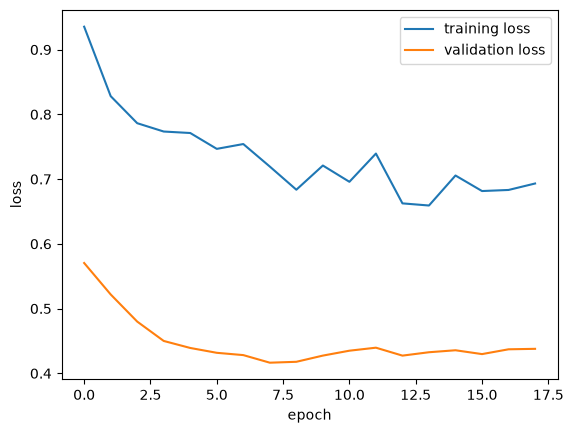

In [3]:
model = rnn(df, column_names_to_difference = ['CPI inflation', 'Unemp rate'], train_years = [1994, 2009], 
            val_years = [2010, 2014], test_years = [2015, 2019])
model.tune_model()

at 4, 8, 12 time lags best config is:
number of lags: 12
1st GRU layer neurons: 32
2nd GRU layer neurons 16
dropout rate: 0.1
batch size is: 32
minimum validation loss reached: 0.4704699218273163
reached after 6 epochs